111111111111111
211111111111111
311111111111111


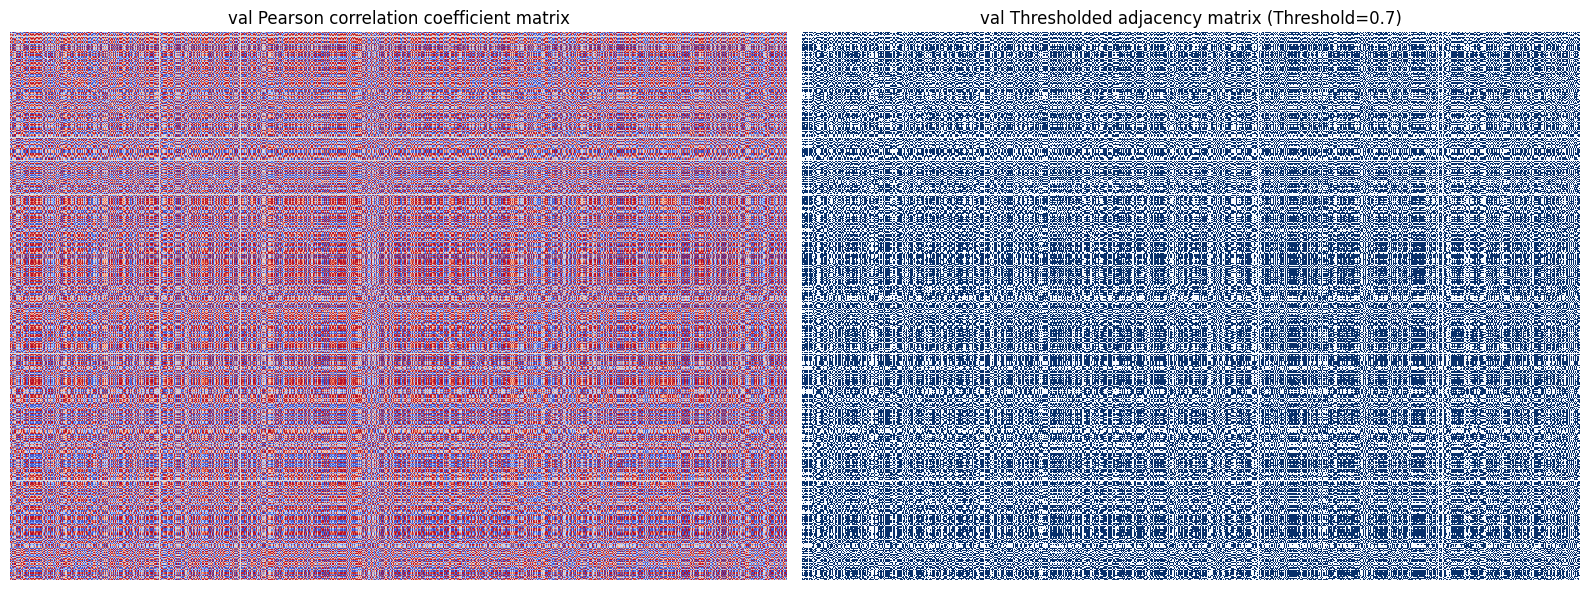

In [ ]:
import pandas as pd
import glob
import os
import torch
import numpy as np
from datetime import datetime
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
# 获取所有 CSV 文件
data_dir = 'NYSE/'
csv_files = glob.glob(os.path.join(data_dir, 'NYSE_*_30Y.csv'))

# 加载公司数据
companies_data = {}
for f in csv_files:
    try:
        company_name = os.path.basename(f).split('_')[1]
        df = pd.read_csv(f)
        df['Date'] = pd.to_datetime(df['Date'], utc=True)
        df['Date'] = df['Date'].dt.tz_convert(None)
        companies_data[company_name] = df
    except Exception as e:
        print(f"Error loading {f}: {e}")

# 定义日期范围
train_start = datetime.strptime('2014-01-01', '%Y-%m-%d')
train_end = datetime.strptime('2014-8-31', '%Y-%m-%d')
# val_start = datetime.strptime('2014-9-01', '%Y-%m-%d')
# val_end = datetime.strptime('2014-9-30', '%Y-%m-%d')
# test_start = datetime.strptime('2013-11-01', '%Y-%m-%d')
# test_end = datetime.strptime('2013-12-31', '%Y-%m-%d')
print("111111111111111")
# 按日期范围划分数据
train_data = {}
val_data = {}
test_data = {}
for company, df in companies_data.items():
    train_data[company] = df[(df['Date'] >= train_start) & (df['Date'] <= train_end)][['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()
    # val_data[company] = df[(df['Date'] >= val_start) & (df['Date'] <= val_end)][['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()
    # test_data[company] = df[(df['Date'] >= test_start) & (df['Date'] <= test_end)][['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()
print("211111111111111")
company_names = list(companies_data.keys())
num_companies = len(company_names)
def pearsonr_torch(x, y, device='cuda'):
    """
    计算两个序列的皮尔逊相关系数（GPU 加速）
    x, y: shape (seq_len,) 的 PyTorch 张量
    """
    x = x.to(device)
    y = y.to(device)
    mean_x = torch.mean(x)
    mean_y = torch.mean(y)
    xm = x - mean_x
    ym = y - mean_y
    cov_xy = torch.sum(xm * ym)
    std_x = torch.sqrt(torch.sum(xm ** 2))
    std_y = torch.sqrt(torch.sum(ym ** 2))
    corr = cov_xy / (std_x * std_y + 1e-10)  # 避免除以零
    return corr

def create_graph_data(dataset, company_names, seq_len, save_dir, split, corr_threshold=0.7, device='cuda'):
    if not os.path.exists(os.path.join(save_dir, split)):
        os.makedirs(os.path.join(save_dir, split))
    
    num_companies = len(company_names)
    num_windows = 0
    
    if device == 'cuda' and not torch.cuda.is_available():
        print("警告：未检测到 GPU，使用 CPU 进行计算")
        device = 'cpu'
    
    min_length = min(len(dataset[company]) for company in company_names if not dataset[company].empty)
    if min_length < seq_len + 1:
        print(f"警告：{split} 集数据不足 (min_length={min_length})")
        return 0
    
    for i in range(min_length - seq_len):
        X = []
        Y = []
        valid_companies = []
        close_prices_window = []
        
        for j, company in enumerate(company_names):
            df = dataset[company]
            if len(df) < seq_len + 1:
                continue
            
            window_data = df.iloc[i:i+seq_len]
            if len(window_data) == seq_len:
                features = window_data[['Open', 'High', 'Low', 'Close', 'Volume']].values
                X.append(features)
                close_prices_window.append(window_data['Close'].values)
                
                current_close = window_data['Close'].iloc[-1]
                next_data = df.iloc[i+seq_len] if i+seq_len < len(df) else None
                if next_data is not None:
                    next_close = next_data['Close']
                    label = 1 if next_close > current_close else 0
                    Y.append(label)
                    valid_companies.append(j)
        
        if len(X) == num_companies and len(Y) == num_companies:
            adj_matrix = np.zeros((num_companies, num_companies))
            corr_matrix = np.zeros((num_companies, num_companies))  # 保存皮尔逊系数
            close_prices_window = np.array(close_prices_window)  
            close_prices_tensor = torch.tensor(close_prices_window, dtype=torch.float32)
            
            for m in range(num_companies):
                for n in range(m + 1, num_companies):
                    if len(close_prices_window[m]) > 1 and len(close_prices_window[n]) > 1:
                        corr = pearsonr_torch(close_prices_tensor[m], close_prices_tensor[n], device)
                        corr_value = corr.item()
                        corr_matrix[m, n] = corr_value
                        corr_matrix[n, m] = corr_value
                        if abs(corr_value) > corr_threshold:
                            adj_matrix[m, n] = 1
                            adj_matrix[n, m] = 1
            
            # 在第一个窗口时绘制两张热力图
            if num_windows == 0:
                fig, axes = plt.subplots(1, 2, figsize=(16, 6))
                
                # 原始皮尔逊相关系数矩阵
                sns.heatmap(corr_matrix, xticklabels=False, yticklabels=False, 
                            cmap="coolwarm", center=0,cbar=False, annot=False, ax=axes[0])
                axes[0].set_title(f"{split} Pearson correlation coefficient matrix")
                
                # 阈值化邻接矩阵
                sns.heatmap(adj_matrix, xticklabels=False, yticklabels=False,
                            cmap="Blues", cbar=False, annot=False, ax=axes[1])
                axes[1].set_title(f"{split} Thresholded adjacency matrix (Threshold={corr_threshold})")
                plt.tight_layout()

                plt.savefig(os.path.join(save_dir, f"{split}_first_matrices.png"), dpi=300)
                plt.savefig(f"{split}_first_matrices.jpg", dpi=300, format='jpg')
                plt.show()
            
            indices = np.vstack(np.where(adj_matrix > 0))
            edge_index = torch.from_numpy(indices).long()
            
            X = torch.from_numpy(np.array(X, dtype=np.float32))  
            Y = torch.tensor(Y, dtype=torch.long)   
            graph_data = {'X': X, 'A': edge_index, 'Y': Y}
            torch.save(graph_data, os.path.join(save_dir, split, f'graph_{num_windows}.pt'))
            num_windows += 1
    
    return num_windows

  
        
      

# 创建并保存图数据
save_dir = './w_3_NYSE_graph_data_2'
seq_len = 3
corr_threshold = 0.7
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("311111111111111")
train_windows = create_graph_data(train_data, company_names, seq_len, save_dir=save_dir, split='train', corr_threshold=corr_threshold, device=device)
# val_windows = create_graph_data(val_data, company_names, seq_len, save_dir=save_dir, split='val', corr_threshold=corr_threshold, device=device)
# test_windows = create_graph_data(test_data, company_names, seq_len, save_dir=save_dir, split='test', corr_threshold=corr_threshold, device=device)
# print(f"创建了 {train_windows} 个训练图、{val_windows} 个验证图、{test_windows} 个测试图数据文件。")